# 03. Exploratory Data Analysis

변수별 분포와 변수 간 관계를 탐색합니다.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows 기준)
plt.rc('font', family='Malgun Gothic') 
plt.rc('axes', unicode_minus=False)

# 데이터 불러오기
df = pd.read_csv('../merged_data.csv')

# 제어전략(Strategy) 파생변수 생성 - Batch_ID 기준 매핑
def get_strategy(bid):
    if bid <= 30: return 'RC'
    elif bid <= 60: return 'OC'
    elif bid <= 90: return 'APC'
    else: return 'Fault'
df['Strategy'] = df['Batch_ID'].apply(get_strategy)

# 컬럼 그룹 정의 (X값 후보만)
core_cols = ['Penicillin concentration(P:g/L)', 'Substrate concentration(S:g/L)',
             'Dissolved oxygen concentration(DO2:mg/L)', 'Vessel Volume(V:L)',
             'pH(pH:pH)', 'Temperature(T:K)']

operating_cols = ['Agitator RPM(RPM:RPM)', 'Sugar feed rate(Fs:L/h)', 'Aeration rate(Fg:L/h)',
                  'Acid flow rate(Fa:L/h)', 'Base flow rate(Fb:L/h)',
                  'Heating/cooling water flow rate(Fc:L/h)', 'Heating water flow rate(Fh:L/h)',
                  'Water for injection/dilution(Fw:L/h)', 'PAA flow(Fpaa:PAA flow (L/h))',
                  'Oil flow(Foil:L/hr)', 'Air head pressure(pressure:bar)',
                  'Generated heat(Q:kJ)', 'Vessel Weight(Wt:Kg)', 'Dumped broth flow(Fremoved:L/h)',
                  'Ammonia shots(NH3_shots:kgs)', 'carbon dioxide percent in off-gas(CO2outgas:%)',
                  'Oxygen in percent in off-gas(O2:O2  (%))', 'Oxygen Uptake Rate(OUR:(g min^{-1}))',
                  'Carbon evolution rate(CER:g/h)']

offline_cols = ['Offline Biomass concentratio(X_offline:X(g L^{-1}))',
                'Offline Penicillin concentration(P_offline:P(g L^{-1}))',
                'PAA concentration offline(PAA_offline:PAA (g L^{-1}))',
                'NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1}))',
                'Viscosity(Viscosity_offline:centPoise)']

y_cols = ['Penicllin_yield_total (kg)', 'Penicllin_harvested_end_of_batch (kg)',
          'Penicllin_harvested_during_batch(kg)']

# 컬럼명
batch_col = 'Batch_ID'
time_col = 'Time (h)'

total_col = 'Penicllin_yield_total (kg)'
during_col = 'Penicllin_harvested_during_batch(kg)'
end_col = 'Penicllin_harvested_end_of_batch (kg)'

p_col = 'Penicillin concentration(P:g/L)'
volume_col = 'Vessel Volume(V:L)'

# 시간순 정렬
df = df.sort_values([batch_col, time_col]).copy()

# 0. 데이터 구조 파악

In [5]:
print("=== 1. 데이터 기본 구조 ===")
print(f"전체 Shape: {df.shape}")
print(f"배치 수: {df['Batch_ID'].nunique()}개")
print()
print("[Strategy 그룹별 배치 수]")
print(df.groupby('Strategy')['Batch_ID'].nunique())
print()
print("[배치별 소요시간(Time) 분포]")
print(df.groupby('Batch_ID')['Time (h)'].max().describe())

=== 1. 데이터 기본 구조 ===
전체 Shape: (113935, 40)
배치 수: 100개

[Strategy 그룹별 배치 수]
Strategy
APC      30
Fault    10
OC       30
RC       30
Name: Batch_ID, dtype: int64

[배치별 소요시간(Time) 분포]
count    100.000000
mean     227.870000
std       18.150691
min      167.000000
25%      227.500000
50%      230.000000
75%      230.000000
max      290.000000
Name: Time (h), dtype: float64


# 1. 총수율 컬럼의 계산 구조 및 단위 스케일 확인

사용 컬럼
배치: Batch_ID
시간: Time (h)
총수율: Penicllin_yield_total (kg)
중간수확량: Penicllin_harvested_during_batch(kg)
종료시수확량: Penicllin_harvested_end_of_batch (kg)

① 배치 내 고유값 개수의 최댓값
Penicllin_yield_total (kg)               1
Penicllin_harvested_during_batch(kg)     1
Penicllin_harvested_end_of_batch (kg)    1
dtype: int64

✅ 세 컬럼 모두 배치별 고정값입니다.

② 총수율 계산오차
             계산오차     상대오차(%)
count  100.000000  100.000000
mean     8.300000    0.000775
std     40.127448    0.001152
min   -100.000000    0.000000
25%      0.000000    0.000000
50%      0.000000    0.000000
75%      0.000000    0.001462
max    100.000000    0.004186

③ 계산오차가 큰 배치 10개
 배치번호 제어전략그룹       총수율     중간수확량    종료시수확량     수확량합계   계산오차  상대오차(%)
    6     RC 2388700.0 1005700.0 1383100.0 2388800.0 -100.0 0.004186
   12     RC 3970100.0 1264400.0 2705600.0 3970000.0  100.0 0.002519
   50     OC 3064900.0 1095000.0 1969800.0 3064800.0  100.0 0.003263
   55     OC 3784400.0 1181200.0 2603100.0 3784300.0  100.0 0.002642
   58     OC 275

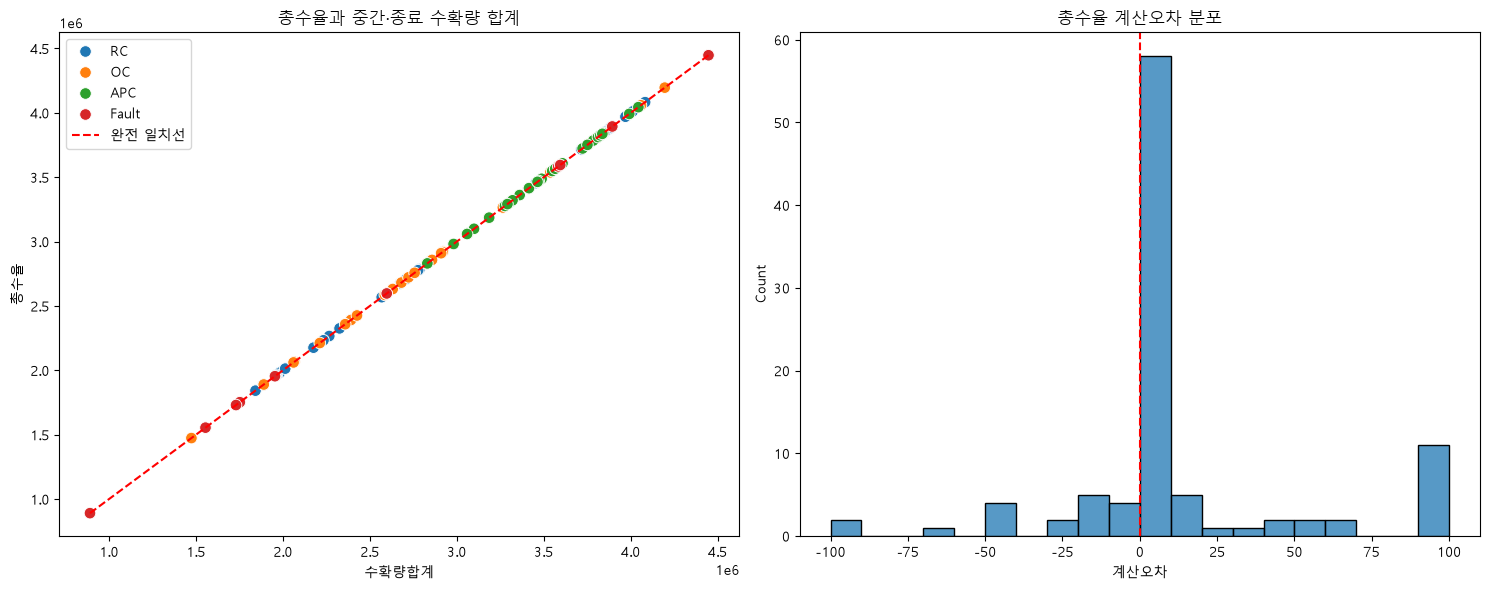

In [17]:
# ============================================================
# 추가 검증 1: 총수율 계산 구조 및 단위 스케일 확인
# 한글/영문 컬럼 자동 대응
# ============================================================

def find_col(korean, english):
    if korean in df.columns:
        return korean
    if english in df.columns:
        return english
    raise KeyError(f'컬럼을 찾지 못했습니다: {korean} / {english}')


# 컬럼 자동 선택
batch_col = find_col('배치번호', 'Batch_ID')
time_col = find_col('발효시간(h)', 'Time (h)')

total_col = find_col(
    '총수율(kg)',
    'Penicllin_yield_total (kg)'
)
during_col = find_col(
    '중간수확량(kg)',
    'Penicllin_harvested_during_batch(kg)'
)
end_col = find_col(
    '종료시수확량(kg)',
    'Penicllin_harvested_end_of_batch (kg)'
)

p_col = find_col(
    '페니실린농도(g/L)',
    'Penicillin concentration(P:g/L)'
)
volume_col = find_col(
    '발효조부피(L)',
    'Vessel Volume(V:L)'
)

# Strategy 컬럼 자동 선택
if '제어전략그룹' in df.columns:
    strategy_col = '제어전략그룹'
elif 'Strategy' in df.columns:
    strategy_col = 'Strategy'
else:
    def get_strategy(batch_id):
        if batch_id <= 30:
            return 'RC'
        elif batch_id <= 60:
            return 'OC'
        elif batch_id <= 90:
            return 'APC'
        else:
            return 'Fault'

    df['Strategy'] = df[batch_col].apply(get_strategy)
    strategy_col = 'Strategy'

print('사용 컬럼')
print('배치:', batch_col)
print('시간:', time_col)
print('총수율:', total_col)
print('중간수확량:', during_col)
print('종료시수확량:', end_col)


# 시간순 정렬
temp = df.sort_values([batch_col, time_col]).copy()

yield_cols = [
    total_col,
    during_col,
    end_col
]

# 1. 배치 내 고정값 여부
unique_check = (
    temp.groupby(batch_col)[yield_cols]
        .nunique()
)

print('\n① 배치 내 고유값 개수의 최댓값')
print(unique_check.max())

if (unique_check.max() == 1).all():
    print('\n✅ 세 컬럼 모두 배치별 고정값입니다.')
else:
    print('\n⚠️ 일부 배치에서 값이 시간에 따라 변합니다.')


# 2. 배치 단위 요약
yield_summary = (
    temp.groupby(batch_col)
        .agg(
            제어전략그룹=(strategy_col, 'first'),
            총수율=(total_col, 'first'),
            중간수확량=(during_col, 'first'),
            종료시수확량=(end_col, 'first'),
            최종페니실린농도=(p_col, 'last'),
            최종발효조부피=(volume_col, 'last')
        )
        .reset_index()
        .rename(columns={batch_col: '배치번호'})
)

# 3. 총수율 계산 확인
yield_summary['수확량합계'] = (
    yield_summary['중간수확량']
    + yield_summary['종료시수확량']
)

yield_summary['계산오차'] = (
    yield_summary['총수율']
    - yield_summary['수확량합계']
)

yield_summary['상대오차(%)'] = (
    yield_summary['계산오차'].abs()
    / yield_summary['총수율'].replace(0, np.nan)
    * 100
)

print('\n② 총수율 계산오차')
print(
    yield_summary[
        ['계산오차', '상대오차(%)']
    ].describe()
)

print('\n③ 계산오차가 큰 배치 10개')
print(
    yield_summary.assign(
        절대오차=yield_summary['계산오차'].abs()
    )
    .nlargest(10, '절대오차')[
        [
            '배치번호',
            '제어전략그룹',
            '총수율',
            '중간수확량',
            '종료시수확량',
            '수확량합계',
            '계산오차',
            '상대오차(%)'
        ]
    ]
    .to_string(index=False)
)


# 4. 단위 스케일 참고 확인
yield_summary['최종시점_단순질량(kg)'] = (
    yield_summary['최종페니실린농도']
    * yield_summary['최종발효조부피']
    / 1000
)

yield_summary['종료수확량_대비배수'] = (
    yield_summary['종료시수확량']
    / yield_summary['최종시점_단순질량(kg)'].replace(0, np.nan)
)

print('\n④ 단위 스케일 참고 결과')
print(
    yield_summary[
        [
            '종료시수확량',
            '최종시점_단순질량(kg)',
            '종료수확량_대비배수'
        ]
    ].describe()
)


# 5. 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(
    data=yield_summary,
    x='수확량합계',
    y='총수율',
    hue='제어전략그룹',
    s=70,
    ax=axes[0]
)

low = min(
    yield_summary['수확량합계'].min(),
    yield_summary['총수율'].min()
)
high = max(
    yield_summary['수확량합계'].max(),
    yield_summary['총수율'].max()
)

axes[0].plot(
    [low, high],
    [low, high],
    'r--',
    label='완전 일치선'
)

axes[0].set_title('총수율과 중간·종료 수확량 합계')
axes[0].legend()

sns.histplot(
    data=yield_summary,
    x='계산오차',
    bins=20,
    ax=axes[1]
)

axes[1].axvline(
    0,
    color='red',
    linestyle='--'
)

axes[1].set_title('총수율 계산오차 분포')

plt.tight_layout()
plt.show()

## 1-2. 배치 단위 요약표 생성

In [13]:
batch_yield_summary = (
    df.groupby(batch_col)
      .agg(
          Strategy=('Strategy', 'first'),
          운전시간=(time_col, 'max'),
          총수율=(total_col, 'first'),
          배치중회수량=(during_col, 'first'),
          종료시회수량=(end_col, 'first'),
          최종농도=(p_col, 'last'),
          최종부피=(volume_col, 'last')
      )
      .reset_index()
)

# 총수율과 두 회수량 합계 비교
batch_yield_summary['회수량합계'] = (
    batch_yield_summary['배치중회수량']
    + batch_yield_summary['종료시회수량']
)

batch_yield_summary['계산오차'] = (
    batch_yield_summary['총수율']
    - batch_yield_summary['회수량합계']
)

batch_yield_summary['상대오차(%)'] = (
    batch_yield_summary['계산오차'].abs()
    / batch_yield_summary['총수율'].replace(0, np.nan)
    * 100
)

print('\n총수율 계산오차 요약')
print(
    batch_yield_summary[
        ['계산오차', '상대오차(%)']
    ].describe()
)

print('\n계산오차가 가장 큰 배치')
print(
    batch_yield_summary.loc[
        batch_yield_summary['계산오차'].abs().idxmax(),
        [
            batch_col,
            '총수율',
            '배치중회수량',
            '종료시회수량',
            '회수량합계',
            '계산오차',
            '상대오차(%)'
        ]
    ]
)


총수율 계산오차 요약
             계산오차     상대오차(%)
count  100.000000  100.000000
mean     8.300000    0.000775
std     40.127448    0.001152
min   -100.000000    0.000000
25%      0.000000    0.000000
50%      0.000000    0.000000
75%      0.000000    0.001462
max    100.000000    0.004186

계산오차가 가장 큰 배치
Batch_ID    6.000000e+00
총수율         2.388700e+06
배치중회수량      1.005700e+06
종료시회수량      1.383100e+06
회수량합계       2.388800e+06
계산오차       -1.000000e+02
상대오차(%)     4.186378e-03
Name: 5, dtype: float64


- 총수율은 시간에 따라 변하는 센서값이 아니라 배치마다 하나씩 부여된 최종 결과값입니다.
- 총수율 ≈ 중간수확량 + 종료시수확량이 맞습니다.
- 최대 상대오차가 0.0042%에 불과하므로 차이는 반올림 수준입니다.
--> 따라서 엄밀히는 ‘기질 대비 수율’보다 총회수량 또는 총생산량에 가깝습니다.
- 단위는 의심스럽습니다. 종료시수확량이 단순 질량 계산보다 중앙값 기준 약 1,009배 큽니다. kg가 아니라 g 단위 값이 - - 잘못 표기됐을 가능성이 있지만, 현재 계산만으로 확정할 수는 없습니다.

단위가 잘못됐더라도 모든 배치에 동일한 스케일이 적용됐다면 순위에는 영향이 없으므로 골든 후보 선정은 가능합니다. 문서에는 일단 데이터셋 제공 총회수량이라고 쓰는 것이 안전합니다.

Train 배치 수: 80
Test 배치 수: 20

Train 전략별 배치 수
Strategy
APC      24
Fault     9
OC       23
RC       24
Name: Batch_ID, dtype: int64

① Pearson 상관계수
         총회수량  시간당생산성   최종농도   최대농도   운전시간
총회수량    1.000   0.949  0.450  0.377 -0.139
시간당생산성  0.949   1.000  0.456  0.341 -0.427
최종농도    0.450   0.456  1.000  0.942 -0.116
최대농도    0.377   0.341  0.942  1.000  0.044
운전시간   -0.139  -0.427 -0.116  0.044  1.000

② Spearman 순위상관계수
         총회수량  시간당생산성   최종농도   최대농도   운전시간
총회수량    1.000   0.942  0.390  0.318 -0.030
시간당생산성  0.942   1.000  0.406  0.297 -0.279
최종농도    0.390   0.406  1.000  0.952 -0.037
최대농도    0.318   0.297  0.952  1.000  0.048
운전시간   -0.030  -0.279 -0.037  0.048  1.000

③ 선정 기준별 상위 20% 후보

[RC]
총회수량 기준      : [9, 12, 26, 8, 17]
시간당생산성 기준 : [17, 12, 26, 8, 9]
최종농도 기준     : [29, 8, 22, 16, 2]

[OC]
총회수량 기준      : [57, 60, 55, 52, 35]
시간당생산성 기준 : [35, 57, 55, 60, 52]
최종농도 기준     : [48, 57, 53, 35, 39]

[APC]
총회수량 기준      : [85, 63, 66, 83, 79]
시간당생산성 기준 : [67, 85, 63, 66, 69]
최종농도 기준 

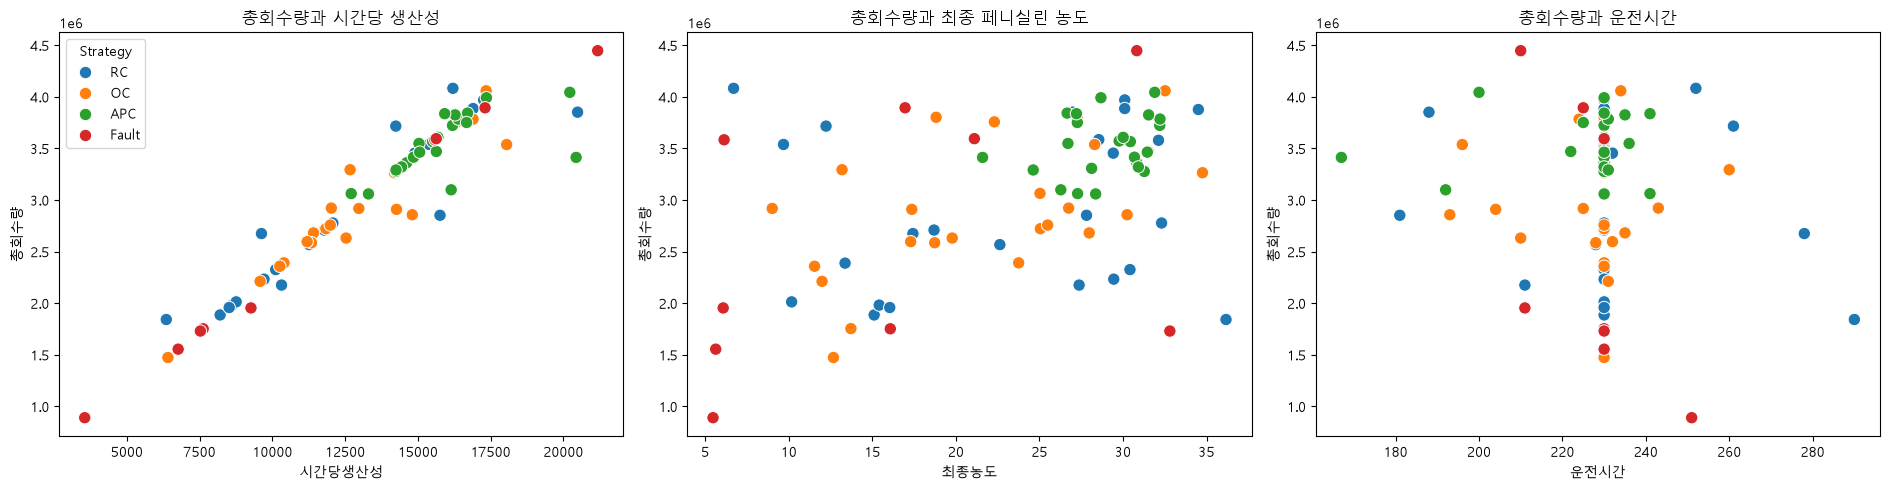

In [18]:
# ============================================================
# 추가 검증 2:
# 총회수량·시간당 생산성·최종 농도 기준의 관계 및 후보 차이
# 반드시 Train 배치만 사용
# ============================================================

import math
from sklearn.model_selection import GroupShuffleSplit

# 컬럼 지정
batch_col = 'Batch_ID'
time_col = 'Time (h)'
total_col = 'Penicllin_yield_total (kg)'
p_col = 'Penicillin concentration(P:g/L)'

# Strategy가 없으면 생성
if 'Strategy' not in df.columns:
    def get_strategy(batch_id):
        if batch_id <= 30:
            return 'RC'
        elif batch_id <= 60:
            return 'OC'
        elif batch_id <= 90:
            return 'APC'
        else:
            return 'Fault'

    df['Strategy'] = df[batch_col].apply(get_strategy)

# ------------------------------------------------------------
# 1. Train/Test 배치 단위 분할
# 기존 변수와 충돌하지 않도록 analysis_train 사용
# ------------------------------------------------------------

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(df, groups=df[batch_col])
)

analysis_train = (
    df.iloc[train_idx]
      .sort_values([batch_col, time_col])
      .copy()
)

analysis_test = df.iloc[test_idx].copy()

train_ids = set(analysis_train[batch_col].unique())
test_ids = set(analysis_test[batch_col].unique())

assert train_ids.isdisjoint(test_ids)

print('Train 배치 수:', len(train_ids))
print('Test 배치 수:', len(test_ids))

print('\nTrain 전략별 배치 수')
print(
    analysis_train.groupby('Strategy')[batch_col]
                  .nunique()
)


# ------------------------------------------------------------
# 2. Train 배치 요약표
# ------------------------------------------------------------

performance_summary = (
    analysis_train.groupby(batch_col)
    .agg(
        Strategy=('Strategy', 'first'),
        총회수량=(total_col, 'first'),
        운전시간=(time_col, 'max'),
        최종농도=(p_col, 'last'),
        최대농도=(p_col, 'max')
    )
    .reset_index()
)

# 시간당 생산성
performance_summary['시간당생산성'] = (
    performance_summary['총회수량']
    / performance_summary['운전시간']
)


# ------------------------------------------------------------
# 3. 성과지표 간 Pearson/Spearman 상관관계
# ------------------------------------------------------------

metric_cols = [
    '총회수량',
    '시간당생산성',
    '최종농도',
    '최대농도',
    '운전시간'
]

pearson_corr = (
    performance_summary[metric_cols]
    .corr(method='pearson')
)

spearman_corr = (
    performance_summary[metric_cols]
    .corr(method='spearman')
)

print('\n① Pearson 상관계수')
print(pearson_corr.round(3))

print('\n② Spearman 순위상관계수')
print(spearman_corr.round(3))


# ------------------------------------------------------------
# 4. RC·OC·APC별 상위 20% 후보 선정
# Fault는 골든 후보에서 제외
# ------------------------------------------------------------

normal_summary = performance_summary[
    performance_summary['Strategy'].isin(
        ['RC', 'OC', 'APC']
    )
].copy()


def get_top_batches(data, metric):
    result = {}

    for strategy in ['RC', 'OC', 'APC']:
        group = data[
            data['Strategy'] == strategy
        ].copy()

        # 상위 20%가 되도록 올림 처리
        n_select = max(
            3,
            math.ceil(len(group) * 0.20)
        )

        selected = group.nlargest(
            n_select,
            metric
        )

        result[strategy] = selected[
            batch_col
        ].tolist()

    return result


top_total = get_top_batches(
    normal_summary,
    '총회수량'
)

top_productivity = get_top_batches(
    normal_summary,
    '시간당생산성'
)

top_final_p = get_top_batches(
    normal_summary,
    '최종농도'
)


print('\n③ 선정 기준별 상위 20% 후보')

for strategy in ['RC', 'OC', 'APC']:
    print(f'\n[{strategy}]')
    print('총회수량 기준      :', top_total[strategy])
    print('시간당생산성 기준 :', top_productivity[strategy])
    print('최종농도 기준     :', top_final_p[strategy])


# ------------------------------------------------------------
# 5. 후보 중복도 계산
# ------------------------------------------------------------

overlap_rows = []

for strategy in ['RC', 'OC', 'APC']:
    a = set(top_total[strategy])
    b = set(top_productivity[strategy])
    c = set(top_final_p[strategy])

    overlap_rows.append({
        'Strategy': strategy,
        '선정수': len(a),
        '총회수량∩생산성': len(a & b),
        '총회수량∩최종농도': len(a & c),
        '세 기준 모두 공통': len(a & b & c),
        '총회수량-생산성 Jaccard': (
            len(a & b) / len(a | b)
        ),
        '총회수량-농도 Jaccard': (
            len(a & c) / len(a | c)
        )
    })

overlap_df = pd.DataFrame(overlap_rows)

print('\n④ 후보 중복도')
print(overlap_df.round(3).to_string(index=False))


# ------------------------------------------------------------
# 6. 시각화
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.scatterplot(
    data=performance_summary,
    x='시간당생산성',
    y='총회수량',
    hue='Strategy',
    s=80,
    ax=axes[0]
)

axes[0].set_title('총회수량과 시간당 생산성')

sns.scatterplot(
    data=performance_summary,
    x='최종농도',
    y='총회수량',
    hue='Strategy',
    s=80,
    legend=False,
    ax=axes[1]
)

axes[1].set_title('총회수량과 최종 페니실린 농도')

sns.scatterplot(
    data=performance_summary,
    x='운전시간',
    y='총회수량',
    hue='Strategy',
    s=80,
    legend=False,
    ax=axes[2]
)

axes[2].set_title('총회수량과 운전시간')

plt.tight_layout()
plt.show()

### 총회수량과 최종 농도는 서로 다른 성과지표!
- 총회수량–생산성: 순위상관 0.942
--\ 거의 같은 배치를 높게 평가
-- 생산성이 총회수량을 운전시간으로 나눈 파생지표라 어느 정도 당연한 결과
- 총회수량–최종 농도: 순위상관 0.390
-- 두 지표의 배치 순위가 상당히 다름
- 총회수량 상위 5개와 최종 농도 상위 5개의 공통 배치:
-- RC 1개
-- OC 2개
-- APC 2개

- 따라서 총회수량 기준 골든배치는 “최종 농도가 높은 배치”가 아니라 “총회수량이 높은 배치”입니다.

① 총회수량 상위 20% 후보의 다른 성과지표 순위
 Batch_ID Strategy      총회수량    시간당생산성   최종농도   최대농도  운전시간  총회수량_백분위  생산성_백분위  최종농도_백분위  최대농도_백분위
       85      APC 4044300.0 20221.500 31.898 31.898 200.0     1.000    0.958     0.917     0.917
       63      APC 3991800.0 17355.652 28.677 28.739 230.0     0.958    0.917     0.458     0.458
       66      APC 3842700.0 16707.391 26.655 26.691 230.0     0.917    0.875     0.167     0.167
       83      APC 3837100.0 15921.577 27.214 27.214 241.0     0.875    0.625     0.250     0.250
       79      APC 3825600.0 16279.149 31.531 31.546 235.0     0.833    0.750     0.875     0.875
       57       OC 4059100.0 17346.581 32.518 32.518 234.0     1.000    0.957     0.957     0.957
       60       OC 3802300.0 16531.739 18.818 25.136 230.0     0.957    0.870     0.435     0.435
       55       OC 3784400.0 16894.643 27.268 28.272 224.0     0.913    0.913     0.783     0.609
       52       OC 3757800.0 16338.261 22.300 26.519 230.0     0.870    0.826     0.522  

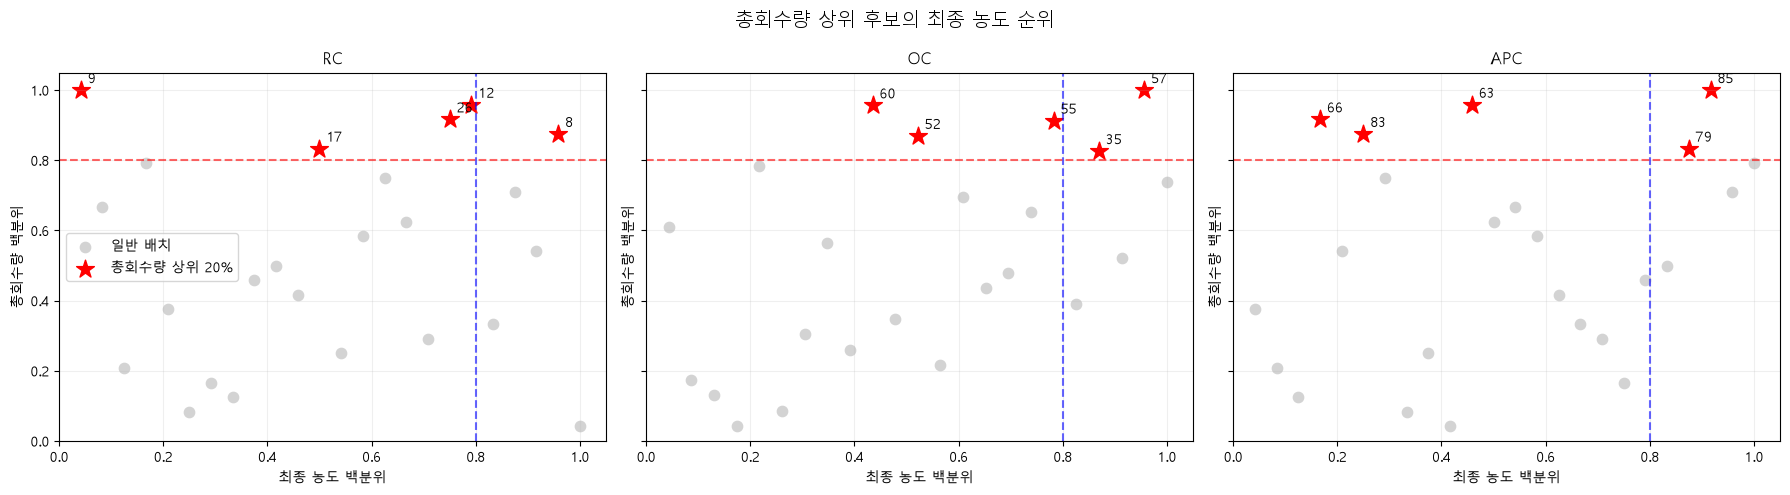

In [19]:
# ============================================================
# 추가 검증 3:
# 총회수량 상위 후보의 최종 농도·생산성 순위 확인
# ============================================================

rank_summary = normal_summary.copy()

# 전략 내 백분위 순위
# 1.0에 가까울수록 해당 전략에서 우수
rank_summary['총회수량_백분위'] = (
    rank_summary.groupby('Strategy')['총회수량']
                .rank(pct=True)
)

rank_summary['생산성_백분위'] = (
    rank_summary.groupby('Strategy')['시간당생산성']
                .rank(pct=True)
)

rank_summary['최종농도_백분위'] = (
    rank_summary.groupby('Strategy')['최종농도']
                .rank(pct=True)
)

rank_summary['최대농도_백분위'] = (
    rank_summary.groupby('Strategy')['최대농도']
                .rank(pct=True)
)

# 총회수량 상위 20% 여부
rank_summary['총회수량_상위20%'] = False

for strategy in ['RC', 'OC', 'APC']:
    group = rank_summary[
        rank_summary['Strategy'] == strategy
    ]

    n_select = max(
        3,
        math.ceil(len(group) * 0.20)
    )

    selected_idx = group.nlargest(
        n_select,
        '총회수량'
    ).index

    rank_summary.loc[
        selected_idx,
        '총회수량_상위20%'
    ] = True


# 총회수량 상위 후보만 출력
candidate_rank_table = (
    rank_summary[
        rank_summary['총회수량_상위20%']
    ]
    [
        [
            'Batch_ID',
            'Strategy',
            '총회수량',
            '시간당생산성',
            '최종농도',
            '최대농도',
            '운전시간',
            '총회수량_백분위',
            '생산성_백분위',
            '최종농도_백분위',
            '최대농도_백분위'
        ]
    ]
    .sort_values(
        ['Strategy', '총회수량'],
        ascending=[True, False]
    )
)

print('① 총회수량 상위 20% 후보의 다른 성과지표 순위')
print(
    candidate_rank_table.round(3)
                        .to_string(index=False)
)


# 최종 농도가 하위 50%인 총회수량 상위 후보
low_p_candidates = candidate_rank_table[
    candidate_rank_table['최종농도_백분위'] < 0.5
]

print('\n② 총회수량은 상위 20%지만 최종 농도는 하위 50%인 후보')
if len(low_p_candidates) == 0:
    print('해당 배치 없음')
else:
    print(
        low_p_candidates.round(3)
                        .to_string(index=False)
    )


# 최종 농도도 상위 20%인 후보
both_high = candidate_rank_table[
    candidate_rank_table['최종농도_백분위'] > 0.8
]

print('\n③ 총회수량과 최종 농도가 모두 상위 20%인 후보')
if len(both_high) == 0:
    print('해당 배치 없음')
else:
    print(
        both_high.round(3)
                 .to_string(index=False)
    )


# ------------------------------------------------------------
# 시각화: 전략 내 총회수량 순위와 최종 농도 순위
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5),
    sharex=True,
    sharey=True
)

for ax, strategy in zip(
    axes,
    ['RC', 'OC', 'APC']
):
    group = rank_summary[
        rank_summary['Strategy'] == strategy
    ]

    normal_points = group[
        ~group['총회수량_상위20%']
    ]

    selected_points = group[
        group['총회수량_상위20%']
    ]

    # 일반 배치
    ax.scatter(
        normal_points['최종농도_백분위'],
        normal_points['총회수량_백분위'],
        color='lightgray',
        s=55,
        label='일반 배치'
    )

    # 총회수량 상위 후보
    ax.scatter(
        selected_points['최종농도_백분위'],
        selected_points['총회수량_백분위'],
        color='red',
        marker='*',
        s=180,
        label='총회수량 상위 20%'
    )

    # 후보 배치번호 표시
    for _, row in selected_points.iterrows():
        ax.annotate(
            int(row['Batch_ID']),
            (
                row['최종농도_백분위'],
                row['총회수량_백분위']
            ),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=10
        )

    # 상위 20% 경계선
    ax.axvline(
        0.8,
        color='blue',
        linestyle='--',
        alpha=0.6
    )

    ax.axhline(
        0.8,
        color='red',
        linestyle='--',
        alpha=0.6
    )

    ax.set_title(strategy)
    ax.set_xlabel('최종 농도 백분위')
    ax.set_ylabel('총회수량 백분위')
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.2)

axes[0].legend()

plt.suptitle(
    '총회수량 상위 후보의 최종 농도 순위',
    fontsize=14
)

plt.tight_layout()
plt.show()